## Compute the output gradiant img with given filter mask
__Work Flow__
1. Transform the h(x,y) to matrix form
2. Establish axis with x for down, y for right
3. Convolution the original img with filter according to equation $$g(x,y)=f(x,y)*h(x,y)=\Sigma^1_{j=-1}\Sigma^1_{i=-1}h(i,j)f(x-i,y-j)$$

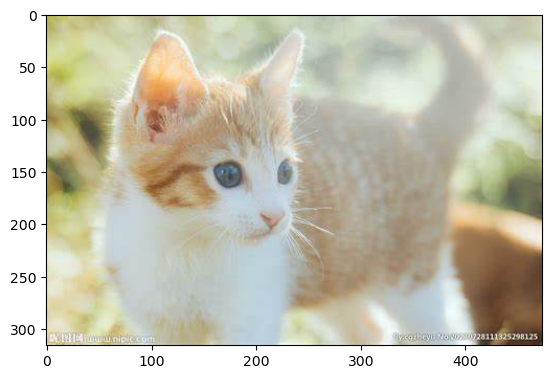

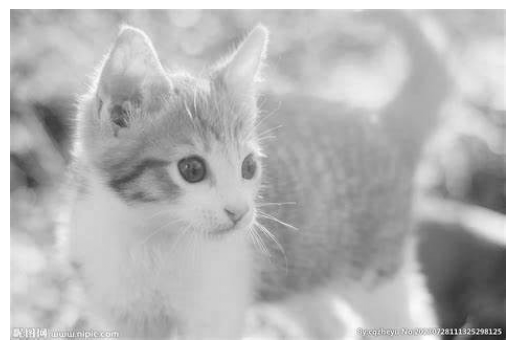

[[0 0 0 0 0]
 [0 1 2 3 0]
 [0 4 5 6 0]
 [0 7 8 9 0]
 [0 0 0 0 0]]
[[-5 -6  0]
 [-8 -8  2]
 [ 0  4  5]]


In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img_cv = cv2.imread("Pictures/T1.jpeg")
img_orig = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
plt.imshow(img_orig)
plt.show()

height, width, channels = img_orig.shape
img_gray = np.zeros((height, width), dtype=np.uint8)

for i in range(height):
    for j in range(width):
        pixel = img_orig[i,j]
        g_pixel = int(np.clip((int(pixel[0]) + int(pixel[1]) + int(pixel[2])) / 3, 0, 255))
        img_gray[i,j] = g_pixel

plt.imshow(img_gray, cmap='gray')
plt.axis('off')
plt.show()
plt.imsave("Pictures/T1_gray.png", img_gray, cmap='gray')

##Assume h(x,y)=\delta(x-1,y-1)-delta(x+1,y+1)
##matrix should be [[-1,0,0],
##                  [0,0,0],
##                  [0,0,1]]
filter_mask = np.array([[-1, 0, 0],
                        [0, 0, 0],
                        [0, 0, 1]])
k=filter_mask.shape[0]
pad=k//2
test=np.array([[1,2,3],[4,5,6],[7,8,9]])
img_padded=np.pad(test, ((pad,pad),(pad,pad)), 'constant', constant_values=0)
print(img_padded)
t_h,t_w=3,3
img_output=np.zeros((t_h, t_w), dtype=np.int8)
for x in range(t_h):
    for y in range(t_w):
        sum=0
        for i in range(-pad,pad+1):
            for j in range(-pad,pad+1):
                sum+=img_padded[x-i+pad,y-j+pad]*filter_mask[i+pad,j+pad]
        img_output[x,y]=sum
print(img_output)




In [14]:
## define largest number
LARGE_NUM=1e10
A=np.array([0,1,6,9])
B=np.array([-3,-4,-4,-5])
t_sample=-1
## Minimun Euclidian Distance classifier
def Euclidian_classifier(A,B,t):
    u_A=np.mean(A)
    u_B=np.mean(B)
    d_A=(u_A-t)*(u_A-t)
    d_B=(u_B-t)*(u_B-t)
    if d_A<d_B: return 'A'
    else: return 'B'
print(Euclidian_classifier(A,B,t_sample))

## 1_st Nearest Neighbor classifier
def nearest_neighbor(A,t):
    d_min=LARGE_NUM
    for s in A:
       d_temp=(s-t)**2
       if d_temp<=d_min: d_min=d_temp
    return d_min
def classifier(A,B,t):
    d_min_A=nearest_neighbor(A,t)
    d_min_B=nearest_neighbor(B,t)
    if d_min_A<d_min_B: return 'A'
    else: return 'B'
print(classifier(A,B,t_sample))

LARGE_NUM=1e10
##minimum Mahalanobis Distance classifier
def Mahalanobis_classifier(A,B,t):
    u_A=np.mean(A)
    u_B=np.mean(B)
    Sigma_A=0
    for a in A:
        Sigma_A+=(a-u_A)*(a-u_A)
    Sigma_A=Sigma_A/len(A)
    d_A=(t-u_A)*(t-u_A)/Sigma_A
    Sigma_B=0
    for b in B:
        Sigma_B+=(b-u_B)*(b-u_B)
    Sigma_B=Sigma_B/len(B)
    d_B=(t-u_B)*(t-u_B)/Sigma_B
    if d_A<d_B: return 'A'
    else: return 'B'
print(Mahalanobis_classifier(A,B,t_sample))

B
A
A


## MAP Decision
Maximun A Postorior Probability Decision refers to find the max $P(w_i|x)$, under the given condition x, the test sample t's probability belons to class $w_i$.  

However, the $P(w_i\|x)$ usually cannot directly get, often get $P(x|w_i)$, $P(w_i)$ and $P(x)$.  

According to Bayes equation, we can easily compute it: $$P(w_i|x)=\frac{P(x|w_i)*P(w_i)}{P(x)}$$
Where $$P(x)=\Sigma^c_{i=1} P(x|w_i)*P(w_i),\quad\text{c is the \# of classes}$$
The error rate $$P(e_i|x)=1-P(w_i|x)$$

In [15]:
## MAP Decision
x=1.5
P_wA=0.6
P_wB=0.4
def Gaussian(x,u,sigma):
    return 1/(np.sqrt(2*np.pi)*sigma)*np.exp(-(x-u)**2/(2*sigma**2))
def MAP_classifier(x,P_wA,P_wB):
    u_A=np.mean(A)
    u_B=np.mean(B)
    Sigma_A=0
    for a in A:
        Sigma_A+=(a-u_A)*(a-u_A)
    Sigma_A=Sigma_A/len(A)
    P_x_wA=Gaussian(x,u_A,np.sqrt(Sigma_A))
    u_B=np.mean(B)
    Sigma_B=0
    for b in B:
        Sigma_B+=(b-u_B)*(b-u_B)
    Sigma_B=Sigma_B/len(B)
    P_x_wB=Gaussian(x,u_B,np.sqrt(Sigma_B))
    P_wA_x=P_x_wA*P_wA/(P_x_wA*P_wA+P_x_wB*P_wB)
    P_wB_x=P_x_wB*P_wB/(P_x_wA*P_wA+P_x_wB*P_wB)
    if P_wA_x>P_wB_x: return 'A'
    else: return 'B'
print(MAP_classifier(x,P_wA,P_wB))

A
